Dataset: Kaggle competition `jigsaw-toxic-comment-classification-challenge`, `train.csv`, 159,571 rows

Contains **159,571** rows of comments, a wikipedia talk-page comment from the Jigsaw dataset


### Phase 1 of EDA: 

Goals:

Cleaning if needed

Confirm label distributions and imbalance
    
    
    


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/train.csv")

In [19]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_length,severity_count
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.00000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805,394.01922,0.219952
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420,590.55143,0.748260
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,96.00000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,205.00000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,435.00000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5000.00000,6.000000


Noticed that `comment_text` has HTML elements: not sure how prevalent. Worth cleaning and investigating
 

In [12]:
import re
import html

def clean_html(text):
    if pd.isna(text):
        return None
    text = html.unescape(text)
    return re.sub(r'<[^>]+>', '', text)

df['comment_text_cleaned'] = df['comment_text'].apply(clean_html)
df['comment_length'] = df['comment_text_cleaned'].str.len()

pre_clean = df['comment_text'].str.len()
print(f'Average Comment Length Before Clean:', round(float(pre_clean.mean()),3) )
print(f'Average Comment Length After Clean:', round(float(df['comment_length'].mean()),3 ) )
df.head()

Average Comment Length Before Clean: 394.073
Average Comment Length After Clean: 394.019


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_text_cleaned,comment_length
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,Explanation\nWhy the edits made under my usern...,264
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,D'aww! He matches this background colour I'm s...,112
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,"Hey man, I'm really not trying to edit war. It...",233
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,"""\nMore\nI can't make any real suggestions on ...",622
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,"You, sir, are my hero. Any chance you remember...",67


Added a `comment_length` column to our dataframe. Not a large difference before and after cleaning: HTML elements are not very present `\n` is just to indicate a line break in the comments



Investigating the distribution of tags across `comment_text`


(0.0, 164847.9)

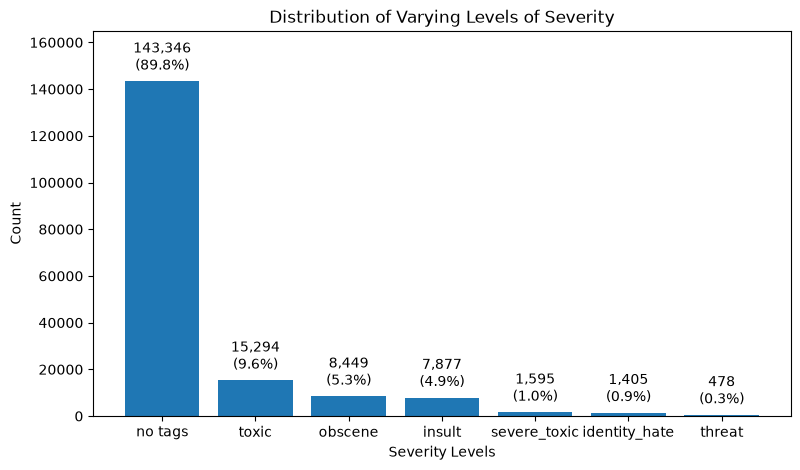

In [13]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
counts = df[labels].sum()
counts['no tags'] = (df[labels].sum(axis=1) == 0).sum()
counts = counts.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(counts.index, counts.values)

for bar in bars:
    ax.annotate(f'{bar.get_height():,.0f}\n({bar.get_height()/len(df):.1%})',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                textcoords='offset points', xytext=(0, 5),
                ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Count')
ax.set_xlabel('Severity Levels')
ax.set_title('Distribution of Varying Levels of Severity')
ax.set_ylim(0, counts.max() * 1.15)

Findings: 
The vast majority of comments are benign with 0 severity tags. `toxic` is the most common tag, following `obscene`, `insult`, `severe_toxic`, and `identity_hate`, with a very small amount of `threat`

Investigating the relationships between variables: starting with `toxic` and `severe_toxic`

Text(0.0, 1.0, 'All 1595 severe_toxic comments are also toxic — 11.643% of toxic Comments')

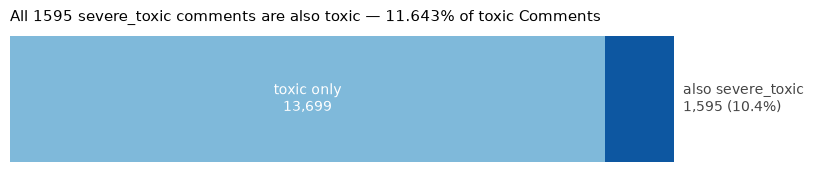

In [14]:
toxic_only = ((df['toxic'] == 1) & (df['severe_toxic'] == 0)).sum()
both = ((df['toxic'] == 1) & (df['severe_toxic'] == 1)).sum()
assert both == df['severe_toxic'].sum()

fig, ax = plt.subplots(figsize = (9,1.8))

ax.barh(0, toxic_only, height = 0.5, color = plt.cm.Blues(0.45), linewidth = 1.5)
ax.barh(0, both, left = toxic_only, height = 0.5, color = plt.cm.Blues(0.85), linewidth = 1.5)
ax.set_yticks([])
ax.set_xticks([])
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

ax.text(toxic_only / 2, 0, f'toxic only\n{toxic_only:,}',
        ha='center', va='center', color='white', fontsize=10)

ax.text(toxic_only + both + 200, 0, f'also severe_toxic\n{both:,} ({both/(toxic_only+both):.1%})',
        ha='left', va='center', color='#444', fontsize=10)

ax.set_title(f'All {df['severe_toxic'].sum()} severe_toxic comments are also toxic — {round(both / toxic_only * 100, 3)}% of toxic Comments',
             loc='left', fontsize=11)


Out of 13,699 `toxic_only` rows, 1,569 (10.4%) of all toxic comments are `severe_toxic`



Text(0.5, 1.0, 'Distribution of Severity Tags Per Comment')

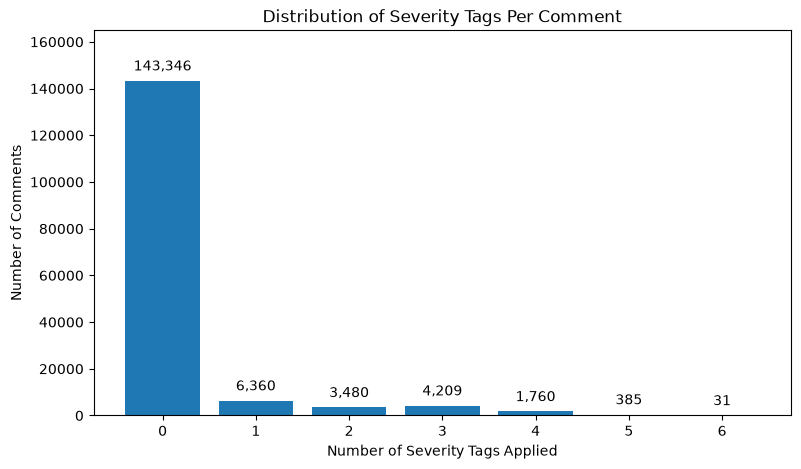

In [15]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
df['severity_count'] = df[labels].sum(axis=1)

severity_counts = df['severity_count'].value_counts().sort_index()


fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(severity_counts.index, severity_counts.values)

for bar in bars:
    ax.annotate(f'{bar.get_height():,.0f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                textcoords='offset points', xytext=(0, 5),
                ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, severity_counts.max() * 1.15)
plt.xlabel("Number of Severity Tags Applied")
plt.ylabel("Number of Comments")
plt.title("Distribution of Severity Tags Per Comment")


Surprising finding from the graph: 4,209 comments have 3 severity tags and 3,480 only have 3. This is around a 20% difference and needs further investigation.



In [16]:
two_severity_tags = df[df['severity_count'] == 2]

two_severity_tags[labels].sum()

two_severity_tags.groupby(labels).size().sort_values(ascending = False)

toxic  severe_toxic  obscene  threat  insult  identity_hate
1      0             1        0       0       0                1758
                     0        0       1       0                1215
0      0             1        0       1       0                 181
1      0             0        0       0       1                 136
                              1       0       0                 113
       1             0        0       0       0                  41
0      0             0        0       1       1                  28
                              1       1       0                   3
                     1        0       0       1                   3
                              1       0       0                   2
dtype: int64

In [17]:
three_severity_tags = df[df['severity_count'] == 3]

three_severity_tags[labels].sum()

three_severity_tags.groupby(labels).size().sort_values(ascending = False)

toxic  severe_toxic  obscene  threat  insult  identity_hate
1      0             1        0       1       0                3800
       1             1        0       0       0                 158
       0             0        0       1       1                 134
                     1        0       0       1                  35
0      0             1        0       1       1                  18
1      0             0        1       1       0                  16
       1             0        0       1       0                  14
       0             1        1       0       0                  11
       1             0        1       0       0                  11
       0             0        1       0       1                   7
       1             0        0       0       1                   3
0      0             1        1       1       0                   2
dtype: int64

`two_severity_tags` is a majority mixture of `toxic` and `obscene` tags along with `toxic` and `insult`

`three_severity_tags` is vastly `toxic`, `obscene`, and `insult`. That combination alone (3,800 occurrences) is greater than the number of `two_severity_tags`

`toxic`, `obscene`, and `insult` match up together because of overlapping language that is considered. Obscene language is largely used for insults and is more common than insults without obscene language.

### Findings From Phase 1

Data Cleaning
- HTML entities/tags exist in `comment_text` but are rare enough that cleaning barely makes a dent in average `comment_length` - average 394.073 chars before, 394.019 after

Label distribution / imbalance
- Dataset is heavily skewed towards comments with 0 tags ~90% of all comments have no tags
- Among the tags, `toxic` is the most common, followed by `obscene`, `insult`, `severe_toxic`, and `identity_hate`, with threat a distant last.
toxic / severe toxic relationship
- `severe_toxic` is a confirmed strict subset of `toxic` (verified via assert) 
- Of `toxic` comments, 10.4% (1,569 of 15,268) are also flagged `severe_toxic`.

Multi-label co-occurrence
- Counts do not strictly decrease as more tags are applied - more occurrence with 3 tags than 2 tags
- Three tag bucket is dominated by one combination: `toxic` + `obscene` + `insult` together accounts for 3,800 of those 4,209 three-tag comments — on its own, more comments than the entire two-tag bucket.
- The two-tag bucket is similarly dominated by two combinations: `toxic` + `obscene` (1,758) and `toxic` + `insult` (1,215).
- Interpretation: toxic, obscene, and insult cluster together because they likely share common traits: obscene language is used in insults more often than non-obscene language

In [18]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

/Users/ec/Documents/projects/content-health-classifier/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
